🤖 SYSTÈME DE DÉTECTION DE MASQUES FACIAUX

⚙️  PyTorch version: 2.9.1+cpu
🔧 CUDA disponible: False

Choisissez le mode:
1. Mode normal (recommandé)
2. Mode débogage ultra-simple
3. Quitter
🔍 TESTEUR DE MODÈLE DE DÉTECTION DE MASQUES

📁 Vérification des fichiers...
✅ 'mask_detection_model.pth' trouvé
✅ 'mask_detection_weights.pth' trouvé

🔄 Chargement du modèle...
📱 Device: cpu

📂 Contenu du fichier mask_detection_model.pth:
Clés disponibles dans le checkpoint:
  - model_state_dict: <class 'collections.OrderedDict'>
  - optimizer_state_dict: <class 'dict'>
  - epoch: <class 'int'>
  - class_names: <class 'dict'>

🔧 Création du modèle...

⚙️ Chargement des poids...
❌ Méthode 1 échouée: Error(s) in loading state_dict for ResNet:
	Unexpected key(s) in state_dict: "fc.out_features.weight...
✅ Méthode 2: Chargement réussi avec checkpoint direct (strict=False)

✅ Modèle chargé avec succès!
📊 Nombre de paramètres: 21,286,211

🔍 VÉRIFICATION DE LA STRUCTURE DU MODÈLE

📐 Dernière couche (fc):
  

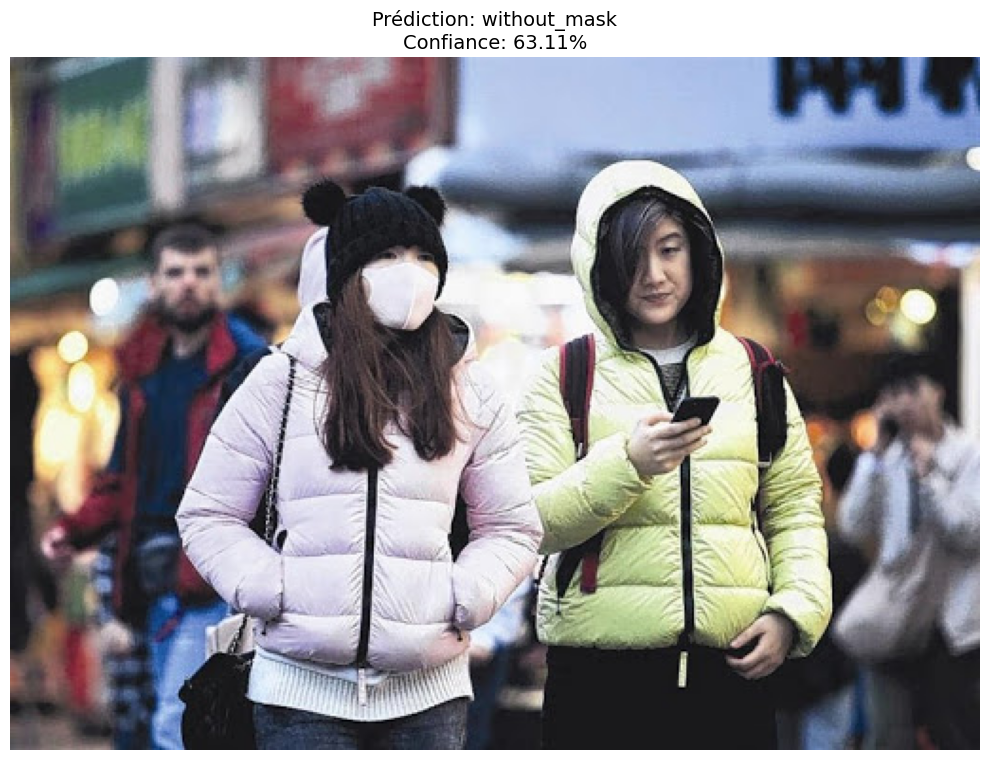


Options:
1. Tester une image
2. Quitter

👋 Au revoir!


In [ ]:
# test_model.py - VERSION CORRIGÉE
import torch
import torch.nn.functional as F
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ARCHITECTURE EXACTEMENT COMME DANS VOTRE CODE D'ENTRAÎNEMENT
# ============================================

def create_model():
    """
    Créer exactement le même modèle que dans votre code d'entraînement
    """
    # Charger ResNet34 pré-entraîné
    model = models.resnet34(pretrained=True)
    
    # Geler les paramètres (comme dans votre code)
    for param in model.parameters():
        param.requires_grad = False
    
    # Remplacer la dernière couche
    n_inputs = model.fc.in_features
    model.fc = nn.Linear(n_inputs, 3)
    
    # Dégeler les dernières couches (comme dans votre code)
    ct = 0
    for child in model.children():
        ct += 1
        if ct < 7:
            for param in child.parameters():
                param.requires_grad = False
    
    return model

# ============================================
# 2. CHARGER LE MODÈLE (CORRIGÉ)
# ============================================

def load_model(model_path='mask_detection_model.pth'):
    """Charger le modèle entraîné - VERSION CORRIGÉE"""
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"📱 Device: {device}")
    
    # 1. D'abord, voir ce qui est dans le fichier
    print(f"\n📂 Contenu du fichier {model_path}:")
    checkpoint = torch.load(model_path, map_location=device)
    
    print("Clés disponibles dans le checkpoint:")
    for key in checkpoint.keys():
        print(f"  - {key}: {type(checkpoint[key])}")
    
    # 2. Créer le modèle AVEC LA BONNE ARCHITECTURE
    print("\n🔧 Création du modèle...")
    model = models.resnet34(pretrained=False)  # Ne pas charger les poids ImageNet
    
    # Modifier la dernière couche pour avoir 3 classes
    n_inputs = model.fc.in_features
    model.fc = nn.Linear(n_inputs, 3)
    
    # 3. Charger les poids - ESSAYER DIFFÉRENTES MÉTHODES
    print("\n⚙️ Chargement des poids...")
    
    # Méthode 1: Essayer de charger directement
    try:
        model.load_state_dict(checkpoint['model_state_dict'], strict=True)
        print("✅ Méthode 1: Chargement réussi avec 'model_state_dict'")
    except Exception as e:
        print(f"❌ Méthode 1 échouée: {str(e)[:100]}...")
        
        # Méthode 2: Essayer avec 'state_dict' directement
        try:
            model.load_state_dict(checkpoint, strict=False)
            print("✅ Méthode 2: Chargement réussi avec checkpoint direct (strict=False)")
        except Exception as e2:
            print(f"❌ Méthode 2 échouée: {str(e2)[:100]}...")
            
            # Méthode 3: Essayer de charger juste les poids (si sauvegardés séparément)
            try:
                weights = torch.load('mask_detection_weights.pth', map_location=device)
                model.load_state_dict(weights)
                print("✅ Méthode 3: Chargement réussi avec 'mask_detection_weights.pth'")
            except Exception as e3:
                print(f"❌ Méthode 3 échouée: {str(e3)[:100]}...")
                
                # Méthode 4: Ajustement manuel des clés
                print("\n🛠️ Tentative d'ajustement des clés...")
                model_dict = model.state_dict()
                
                # Vérifier la structure du checkpoint
                checkpoint_keys = list(checkpoint.keys() if 'model_state_dict' not in checkpoint else checkpoint['model_state_dict'].keys())
                model_keys = list(model_dict.keys())
                
                print(f"\nComparaison des clés:")
                print(f"Premières clés du checkpoint: {checkpoint_keys[:5]}")
                print(f"Premières clés du modèle: {model_keys[:5]}")
                print(f"\nDernières clés du checkpoint: {checkpoint_keys[-5:]}")
                print(f"Dernières clés du modèle: {model_keys[-5:]}")
                
                # Si le checkpoint contient 'model_state_dict'
                if 'model_state_dict' in checkpoint:
                    pretrained_dict = checkpoint['model_state_dict']
                else:
                    pretrained_dict = checkpoint
                
                # Filtrer les clés
                pretrained_dict = {k: v for k, v in pretrained_dict.items() 
                                 if k in model_dict and v.size() == model_dict[k].size()}
                
                # Charger les poids filtrés
                model_dict.update(pretrained_dict)
                model.load_state_dict(model_dict)
                print(f"✅ Chargé {len(pretrained_dict)}/{len(model_dict)} couches")
    
    model = model.to(device)
    model.eval()  # Mode évaluation
    
    print(f"\n✅ Modèle chargé avec succès!")
    print(f"📊 Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")
    
    return model, device

# ============================================
# 3. TRANSFORMATIONS (IDENTIQUES À L'ENTRAÎNEMENT)
# ============================================

def get_transform():
    """Mêmes transformations que pendant l'entraînement"""
    transform = transforms.Compose([
        transforms.Resize((226, 226)),
        transforms.ToTensor()
    ])
    return transform

# ============================================
# 4. TEST D'UNE IMAGE (SIMPLIFIÉ)
# ============================================

def test_single_image_simple(image_path, model, device, transform):
    """Tester une image - version simplifiée"""
    if not os.path.exists(image_path):
        print(f"❌ Erreur: L'image '{image_path}' n'existe pas!")
        return None
    
    try:
        # Charger l'image
        img = Image.open(image_path).convert('RGB')
        print(f"📷 Image chargée: {img.size} → redimensionnée en 226x226")
        
        # Appliquer les transformations
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        # Prédiction
        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = F.softmax(outputs, dim=1)
            predicted_idx = torch.argmax(outputs, 1).item()
            confidence = probabilities[0][predicted_idx].item()
        
        # Noms des classes
        class_names = {0: "with_mask", 1: "without_mask", 2: "mask_weared_incorrect"}
        
        prediction = class_names[predicted_idx]
        
        # Résultats
        print("\n" + "="*50)
        print(f"🎯 RÉSULTAT:")
        print(f"   Prédiction: {prediction}")
        print(f"   Confiance: {confidence:.2%}")
        print("\n📈 Détails:")
        for i, prob in enumerate(probabilities[0]):
            print(f"   {class_names[i]}: {prob.item():.2%}")
        
        # Affichage
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Prédiction: {prediction}\nConfiance: {confidence:.2%}", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        return prediction, confidence
        
    except Exception as e:
        print(f"❌ Erreur: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# ============================================
# 5. VÉRIFICATION DU MODÈLE
# ============================================

def verify_model_structure(model):
    """Vérifier la structure du modèle chargé"""
    print("\n" + "="*50)
    print("🔍 VÉRIFICATION DE LA STRUCTURE DU MODÈLE")
    print("="*50)
    
    # Vérifier la dernière couche
    print(f"\n📐 Dernière couche (fc):")
    print(f"   Type: {type(model.fc)}")
    print(f"   in_features: {model.fc.in_features}")
    print(f"   out_features: {model.fc.out_features}")
    
    # Compter les paramètres
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n📊 Paramètres:")
    print(f"   Total: {total_params:,}")
    print(f"   Entraînables: {trainable_params:,}")
    print(f"   Gelés: {total_params - trainable_params:,}")
    
    # Tester avec un tensor aléatoire
    print(f"\n🧪 Test avec tensor aléatoire...")
    test_input = torch.randn(1, 3, 226, 226).to(next(model.parameters()).device)
    with torch.no_grad():
        test_output = model(test_input)
        print(f"   Shape de sortie: {test_output.shape}")
        print(f"   Valeurs de sortie: {test_output}")
    
    return True

# ============================================
# 6. MENU PRINCIPAL SIMPLIFIÉ
# ============================================

def main_simple():
    print("="*60)
    print("🔍 TESTEUR DE MODÈLE DE DÉTECTION DE MASQUES")
    print("="*60)
    
    # Vérifier les fichiers
    print("\n📁 Vérification des fichiers...")
    if not os.path.exists('mask_detection_model.pth'):
        print("❌ Fichier 'mask_detection_model.pth' non trouvé!")
        print("⚠️  Assurez-vous d'avoir:")
        print("   1. Exécuté votre code d'entraînement")
        print("   2. Sauvegardé le modèle")
        print("   3. Que le fichier est dans le même dossier")
        return
    
    print("✅ 'mask_detection_model.pth' trouvé")
    
    if os.path.exists('mask_detection_weights.pth'):
        print("✅ 'mask_detection_weights.pth' trouvé")
    
    # Charger le modèle
    print("\n🔄 Chargement du modèle...")
    try:
        model, device = load_model('mask_detection_model.pth')
    except Exception as e:
        print(f"❌ Erreur lors du chargement: {str(e)}")
        print("\n💡 Solution: Recréez le modèle exactement comme dans l'entraînement")
        return
    
    # Vérifier la structure
    verify_model_structure(model)
    
    # Charger les transformations
    transform = get_transform()
    
    # Demander une image
    print("\n" + "="*60)
    print("📸 TEST AVEC VOTRE PROPRE IMAGE")
    print("="*60)
    
    while True:
        print("\nOptions:")
        print("1. Tester une image")
        print("2. Quitter")
        
        choix = input("\n👉 Votre choix (1 ou 2): ").strip()
        
        if choix == "1":
            print("\n💡 Conseils:")
            print("   - L'image doit être dans le même dossier")
            print("   - Formats supportés: .jpg, .jpeg, .png")
            print("   - Exemple: 'test.jpg' ou 'photo.png'")
            
            image_name = input("\n📁 Nom de l'image (ex: test.jpg): ").strip()
            
            # Nettoyer le nom
            image_name = image_name.strip('"').strip("'").strip()
            
            # Vérifier l'extension
            if not image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("⚠️  Ajoutez l'extension (.jpg, .png)")
                if '.' not in image_name:
                    image_name += '.jpg'
            
            # Tester l'image
            test_single_image_simple(image_name, model, device, transform)
            
        elif choix == "2":
            print("\n👋 Au revoir!")
            break
            
        else:
            print("❌ Choix invalide. Tapez 1 ou 2.")

# ============================================
# 7. VERSION ULTRA-SIMPLE (SI RIEN NE MARCHE)
# ============================================

def ultra_simple_test():
    """Version ultra-simple pour déboguer"""
    print("="*60)
    print("🛠️  MODE DÉBOGAGE ULTRA-SIMPLE")
    print("="*60)
    
    # 1. Créer un modèle simple
    print("\n1. Création d'un modèle de test...")
    model = models.resnet34(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 3)
    
    # 2. Essayer de charger
    print("\n2. Tentative de chargement...")
    try:
        checkpoint = torch.load('mask_detection_model.pth', map_location='cpu')
        
        # Voir ce qu'il y a dedans
        print(f"Type du checkpoint: {type(checkpoint)}")
        
        if isinstance(checkpoint, dict):
            print("Clés disponibles:")
            for key in checkpoint.keys():
                print(f"  - {key}")
            
            # Essayer différentes clés
            if 'model_state_dict' in checkpoint:
                print("\nEssai avec 'model_state_dict'...")
                model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            elif 'state_dict' in checkpoint:
                print("\nEssai avec 'state_dict'...")
                model.load_state_dict(checkpoint['state_dict'], strict=False)
            else:
                print("\nEssai direct...")
                model.load_state_dict(checkpoint, strict=False)
        else:
            print("\nLe checkpoint n'est pas un dict, essai direct...")
            model.load_state_dict(checkpoint, strict=False)
        
        print("✅ Chargement réussi (strict=False)")
        
    except Exception as e:
        print(f"❌ Échec: {str(e)}")
        return None
    
    # 3. Tester avec une image
    print("\n3. Test avec une image...")
    
    # Créer une image test (noise)
    test_image = torch.randn(1, 3, 226, 226)
    
    model.eval()
    with torch.no_grad():
        output = model(test_image)
        print(f"Shape de sortie: {output.shape}")
        print(f"Valeurs: {output}")
        
        # Softmax
        probs = F.softmax(output, dim=1)
        print(f"\nProbabilités:")
        class_names = {0: "with_mask", 1: "without_mask", 2: "mask_weared_incorrect"}
        for i in range(3):
            print(f"  {class_names[i]}: {probs[0][i].item():.2%}")
    
    return model

# ============================================
# EXÉCUTION PRINCIPALE
# ============================================

if __name__ == "__main__":
    print("="*60)
    print("🤖 SYSTÈME DE DÉTECTION DE MASQUES FACIAUX")
    print("="*60)
    
    # Vérifier PyTorch
    print(f"\n⚙️  PyTorch version: {torch.__version__}")
    print(f"🔧 CUDA disponible: {torch.cuda.is_available()}")
    
    # Menu principal
    print("\nChoisissez le mode:")
    print("1. Mode normal (recommandé)")
    print("2. Mode débogage ultra-simple")
    print("3. Quitter")
    
    mode = input("\n👉 Mode (1-3): ").strip()
    
    if mode == "1":
        main_simple()
    elif mode == "2":
        model = ultra_simple_test()
        if model is not None:
            print("\n✅ Le modèle fonctionne! Vous pouvez maintenant tester des images.")
    elif mode == "3":
        print("\n👋 Au revoir!")
    else:
        print("❌ Mode invalide")

In [ ]:
# webcam_simple.py
import torch
import torch.nn.functional as F
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import cv2
import os

# 1. Charger le modèle
model = models.resnet34(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 3)

if os.path.exists('complete_model_20260223_134038.pth'):
    model.load_state_dict(torch.load('complete_model_20260223_134038.pth', map_location='cpu'), strict=False)
    print("✅ Modèle chargé")
else:
    print("⚠️  Modèle factice - Entraînez d'abord!")

model.eval()

# 2. Transformations
transform = transforms.Compose([
    transforms.Resize((226, 226)),
    transforms.ToTensor()
])

# 3. Webcam
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print("🎥 Appuyez sur 'Q' pour quitter...")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    frame = cv2.flip(frame, 1)  #Flips the image horizontally
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) #Converts the image from color to grayscale
    faces = face_cascade.detectMultiScale(gray, 1.1, 5) #Performs the actual face detection


    
    for (x, y, w, h) in faces:
        try:
            face_img = frame[y:y+h, x:x+w]
            face_pil = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
            face_tensor = transform(face_pil).unsqueeze(0)
            
            with torch.no_grad():
                outputs = model(face_tensor)
                pred = torch.argmax(outputs, 1).item()
            
            colors = [(0, 255, 0), (0, 0, 255), (0, 255, 255)]
            labels = ["WITH MASK", "NO MASK", "BAD MASK"]
            
            color = colors[pred]
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, labels[pred], (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        except:
            continue
    
    cv2.imshow('Mask Detection - Press Q to quit', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Terminé!")

c:\Users\nafed\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nafed\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torchvision.models.resnet.ResNet was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torchvision.models.resnet.ResNet])` or the `torch.serialization.safe_globals([torchvision.models.resnet.ResNet])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load 

In [ ]:
est3mlt code hatha elli teht 5ater ki sajlt modell sajlt 
Save complete model (architecture + weights) - larger file but easier to load

In [1]:
# webcam_simple.py
import torch
import torch.nn.functional as F
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import cv2
import os

# 1. Charger le modèle
if os.path.exists('complete_model_20260223_134038.pth'):
    # Load the entire saved model first
    loaded_object = torch.load('complete_model_20260223_134038.pth', map_location='cpu', weights_only=False)
    
    # Check what we loaded and handle accordingly
    if isinstance(loaded_object, dict):
        # It's a state_dict
        model = models.resnet34(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, 3)
        model.load_state_dict(loaded_object, strict=False)
    else:
        # It's a complete model
        model = loaded_object
    
    print("✅ Modèle chargé")
else:
    print("⚠️  Modèle factice - Création d'un modèle non-entraîné...")
    model = models.resnet34(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 3)

model.eval()

# 2. Transformations
transform = transforms.Compose([
    transforms.Resize((226, 226)),
    transforms.ToTensor()
])

# 3. Webcam
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print("🎥 Appuyez sur 'Q' pour quitter...")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    frame = cv2.flip(frame, 1)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    for (x, y, w, h) in faces:
        try:
            face_img = frame[y:y+h, x:x+w]
            face_pil = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
            face_tensor = transform(face_pil).unsqueeze(0)
            
            with torch.no_grad():
                outputs = model(face_tensor)
                probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
                confidence, pred = torch.max(probabilities, 0)
                pred = pred.item()
            
            colors = [(0, 255, 0), (0, 0, 255), (0, 255, 255)]
            labels = ["WITH MASK", "NO MASK", "BAD MASK"]
            
            # Add confidence score to display
            color = colors[pred]
            confidence_text = f"{labels[pred]}: {confidence:.2f}"
            
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, confidence_text, (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        except Exception as e:
            print(f"Error processing face: {e}")
            continue
    
    cv2.imshow('Mask Detection - Press Q to quit', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Terminé!")

✅ Modèle chargé
🎥 Appuyez sur 'Q' pour quitter...
✅ Terminé!


In [ ]:
test image

In [ ]:
import torch
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import os

# 1. build/load the model exactly as during training
model = models.resnet34(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 3)
if os.path.exists('complete_model_20260223_134038.pth'):
    loaded_object = torch.load('complete_model_20260223_134038.pth',
                               map_location='cpu', weights_only=False)
    if isinstance(loaded_object, dict):
        model.load_state_dict(loaded_object, strict=False)
    else:
        model = loaded_object
    print("✅ Modèle chargé")
else:
    print("⚠️ modèle factice – entraînez‑le ou utilisez un .pth existant")
model.eval()

# 2. same transform as training
transform = transforms.Compose([
    transforms.Resize((226, 226)),
    transforms.ToTensor()
])

# 3. test a single image
def predict_image(img_path, model, transform):
    if not os.path.exists(img_path):
        raise FileNotFoundError(img_path)
    img = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs[0], dim=0)
        conf, pred = torch.max(probs, 0)
        pred = pred.item()
    labels = ["WITH MASK", "NO MASK", "BAD MASK"]
    print(f"Prediction: {labels[pred]}  (confidence {conf:.2f})")
    return labels[pred], conf

# example usage
if __name__ == "__main__":
    path = "../test3.jpg"          # <-- put your file name here
    predict_image(path, model, transform)

C:\Users\nafed\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\nafed\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Modèle chargé
Prediction: BAD MASK  (confidence 0.65)
